Installing  & Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Uploading & Loading Dataset

In [3]:
from google.colab import files
uploaded = files.upload()          # ← pick Churn_Modelling.csv

df = pd.read_csv('Churn_Modelling.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Saving Churn_Modelling.csv to Churn_Modelling.csv
Dataset shape: (10000, 14)

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Exploratory Data Analysis

In [4]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

print("\n\nMissing values per column:")
print(df.isnull().sum())

print("\n\nBasic statistics:")
df.describe()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Missing values per column:
RowNumber          0
CustomerId         0
Surname   

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Churn Distribution

Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


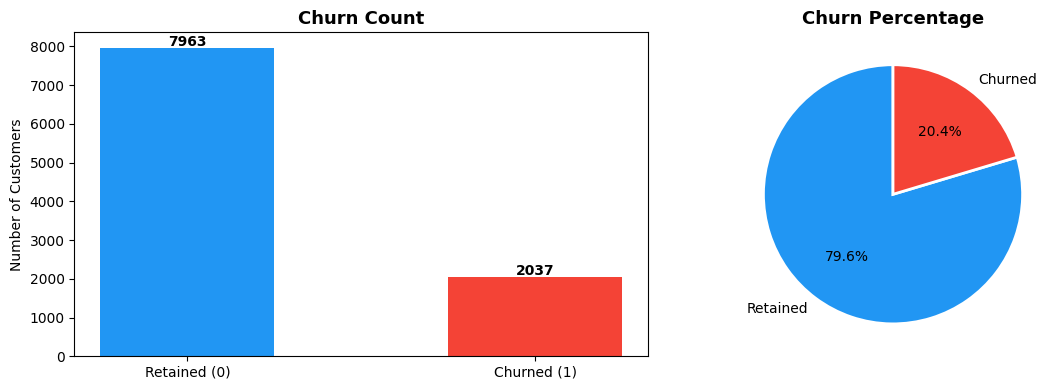

In [6]:
print("Churn distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean() * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Retained (0)', 'Churned (1)'],
            df['Exited'].value_counts().values,
            color=['#2196F3', '#F44336'], width=0.5)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(df['Exited'].value_counts().values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

    # Pie chart
axes[1].pie(df['Exited'].value_counts().values,
            labels=['Retained', 'Churned'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Percentage', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Churn by Categorical Features

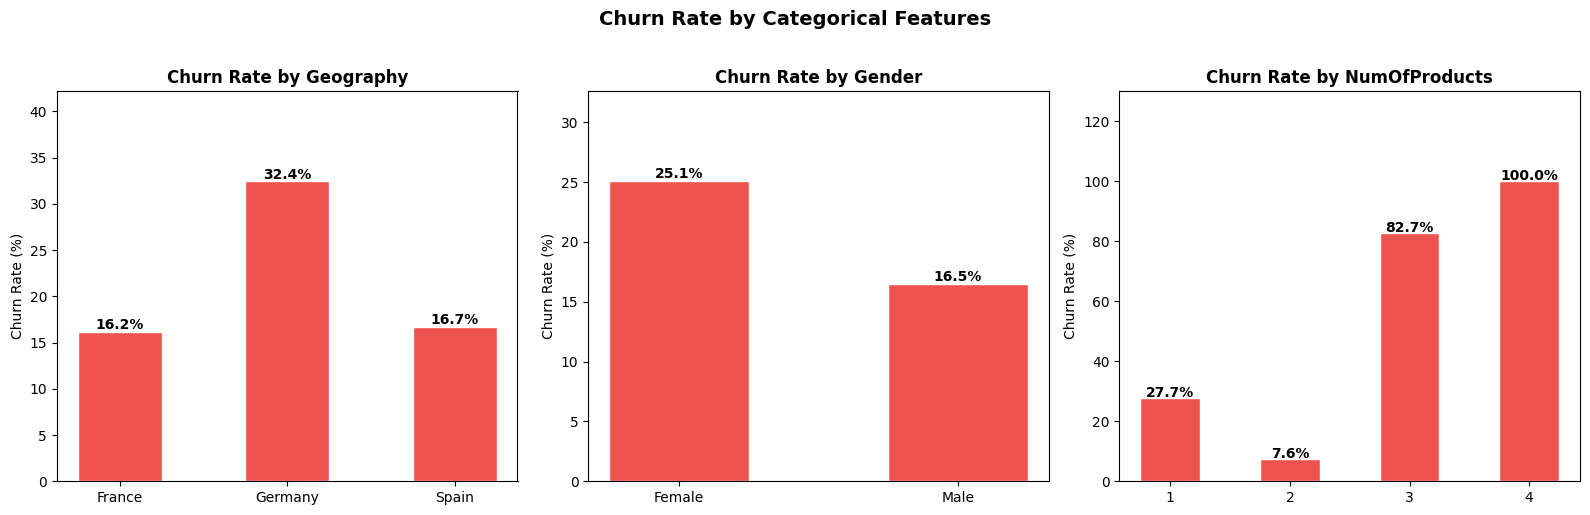

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Geography', 'Gender', 'NumOfProducts']):
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                  color='#EF5350', width=0.5, edgecolor='white')
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.3)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3, f'{val:.1f}%',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

 Churn by Numerical Features

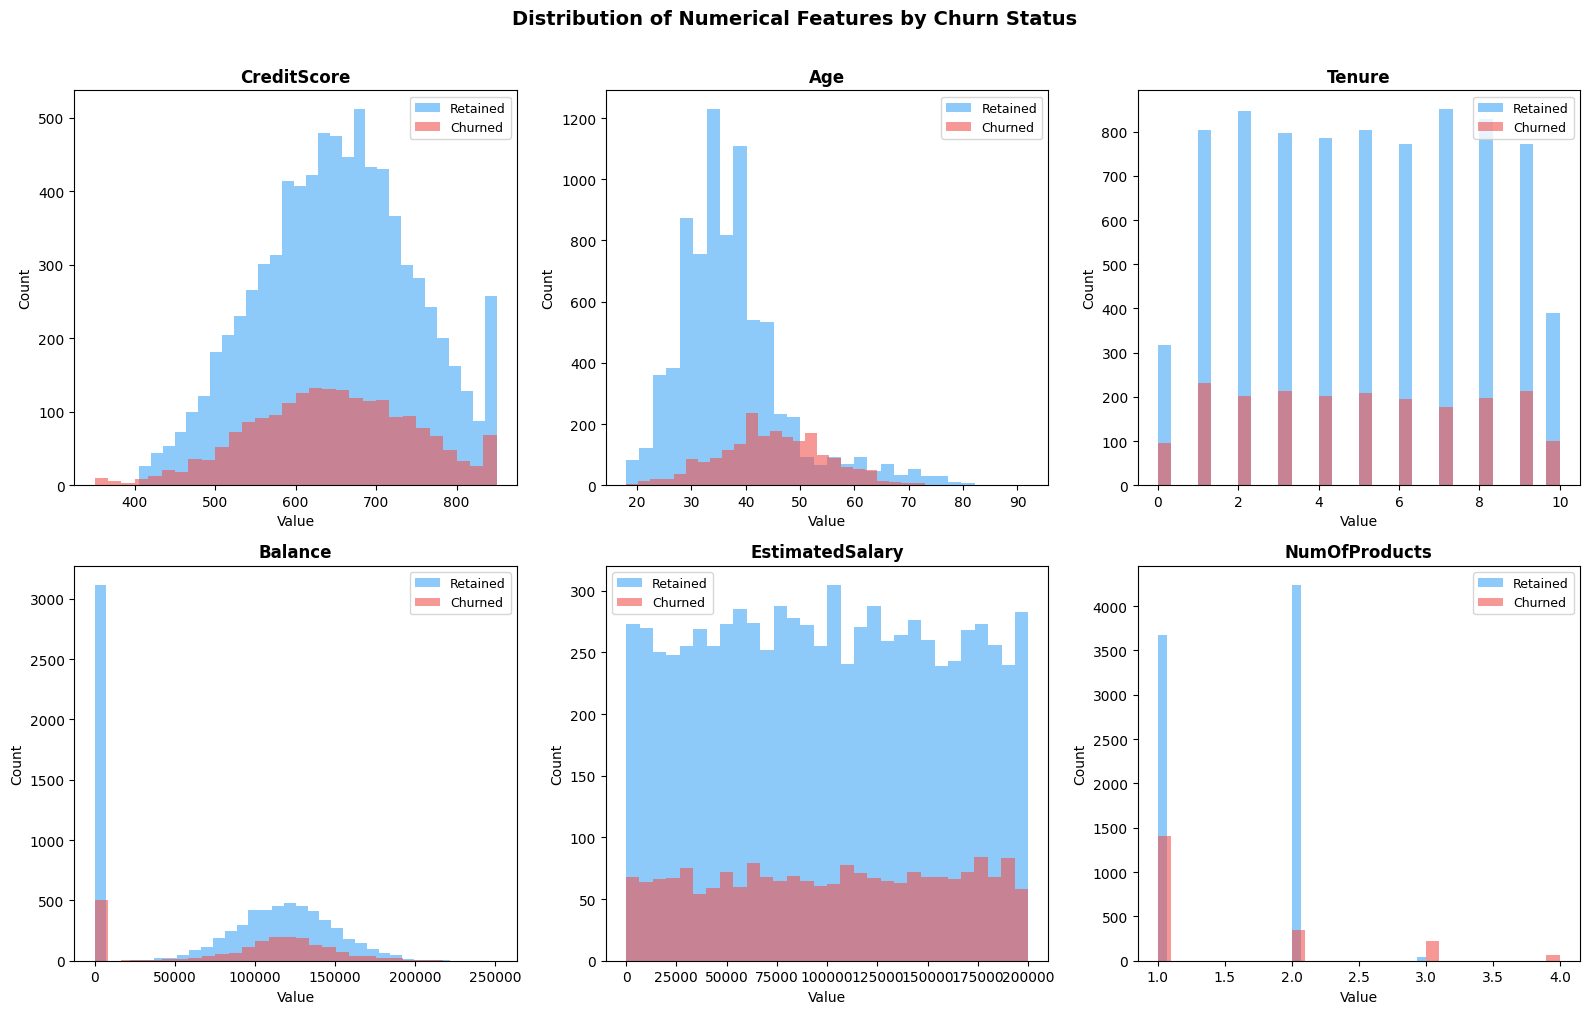

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']
colors = ['#42A5F5', '#EF5350']

for ax, feature in zip(axes, num_features):
    for label, color in zip([0, 1], colors):
        subset = df[df['Exited'] == label][feature]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='Retained' if label == 0 else 'Churned',
                edgecolor='none')
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Numerical Features by Churn Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Heatmap

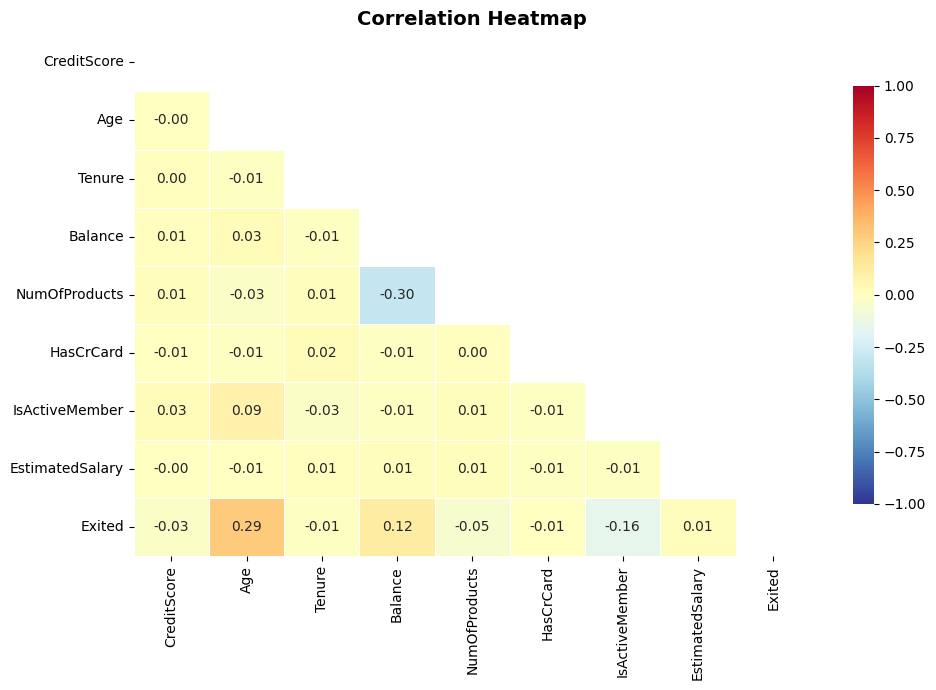

In [9]:
plt.figure(figsize=(10, 7))
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'HasCrCard', 'IsActiveMember',
             'EstimatedSalary', 'Exited']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Data Preparation & Encoding

In [10]:
print("=" * 55)
print("STEP 1: Drop irrelevant columns")
print("=" * 55)

# Drop columns that don't contribute to prediction
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("Dropped: RowNumber, CustomerId, Surname")
print("Remaining features:", list(df_clean.columns))

print("\n" + "=" * 55)
print("STEP 2: Label Encoding — Gender (binary)")
print("=" * 55)

le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])
print(f"Encoding map: Female → 0, Male → 1")
print("Gender value counts:\n", df_clean['Gender'].value_counts())

print("\n" + "=" * 55)
print("STEP 3: One-Hot Encoding — Geography (multi-class)")
print("=" * 55)

df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=False)
print("New columns added:", [c for c in df_clean.columns if 'Geography' in c])
print("Final shape:", df_clean.shape)
print("\nSample of encoded data:")
df_clean.head(3)


STEP 1: Drop irrelevant columns
Dropped: RowNumber, CustomerId, Surname
Remaining features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

STEP 2: Label Encoding — Gender (binary)
Encoding map: Female → 0, Male → 1
Gender value counts:
 Gender
1    5457
0    4543
Name: count, dtype: int64

STEP 3: One-Hot Encoding — Geography (multi-class)
New columns added: ['Geography_France', 'Geography_Germany', 'Geography_Spain']
Final shape: (10000, 13)

Sample of encoded data:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False


Feature / Target Split & Train-Test Split

In [11]:
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

print("Feature matrix X shape:", X.shape)
print("Target vector y shape :", y.shape)
print("\nFeature columns:\n", list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nChurn rate in train : {y_train.mean()*100:.2f}%")
print(f"Churn rate in test  : {y_test.mean()*100:.2f}%")

Feature matrix X shape: (10000, 12)
Target vector y shape : (10000,)

Feature columns:
 ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']

Training set : 8000 samples
Test set     : 2000 samples

Churn rate in train : 20.38%
Churn rate in test  : 20.35%


Standard Scaling (for Logistic Regression)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Scaling done.")


✅ Scaling done.


Train All Models

In [13]:
print("Training models... please wait.\n")

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_prob  = lr.predict_proba(X_test_scaled)[:, 1]

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=42, class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_prob  = rf.predict_proba(X_test)[:, 1]

Training models... please wait.



Gradient Boosting

In [14]:
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=5, random_state=42, subsample=0.8
)
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
gb_prob  = gb.predict_proba(X_test)[:, 1]

print("✅ All 3 models trained!")

✅ All 3 models trained!


 Model Evaluation — Summary Table

In [15]:
results = {
    'Logistic Regression': {'pred': lr_pred, 'prob': lr_prob},
    'Random Forest':        {'pred': rf_pred, 'prob': rf_prob},
    'Gradient Boosting':    {'pred': gb_pred, 'prob': gb_prob},
}

print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC-ROC':>9} {'F1':>9}")
print("=" * 60)

for name, res in results.items():
    acc = accuracy_score(y_test, res['pred']) * 100
    auc = roc_auc_score(y_test, res['prob']) * 100
    f1  = f1_score(y_test, res['pred']) * 100
    print(f"{name:<25} {acc:>8.2f}% {auc:>8.2f}% {f1:>8.2f}%")

print("=" * 60)

Model                      Accuracy   AUC-ROC        F1
Logistic Regression          71.35%    77.71%    49.87%
Random Forest                83.95%    86.16%    61.92%
Gradient Boosting            86.80%    86.54%    60.24%


Detailed Classification Reports

In [16]:
for name, res in results.items():
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(classification_report(y_test, res['pred'],
                                target_names=['Retained (0)', 'Churned (1)']))


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

Retained (0)       0.90      0.72      0.80      1593
 Churned (1)       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

Retained (0)       0.91      0.89      0.90      1593
 Churned (1)       0.60      0.64      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000


───────────────────────────────────────────────────────
  Gradient Boosting
─────

Confusion Matrices

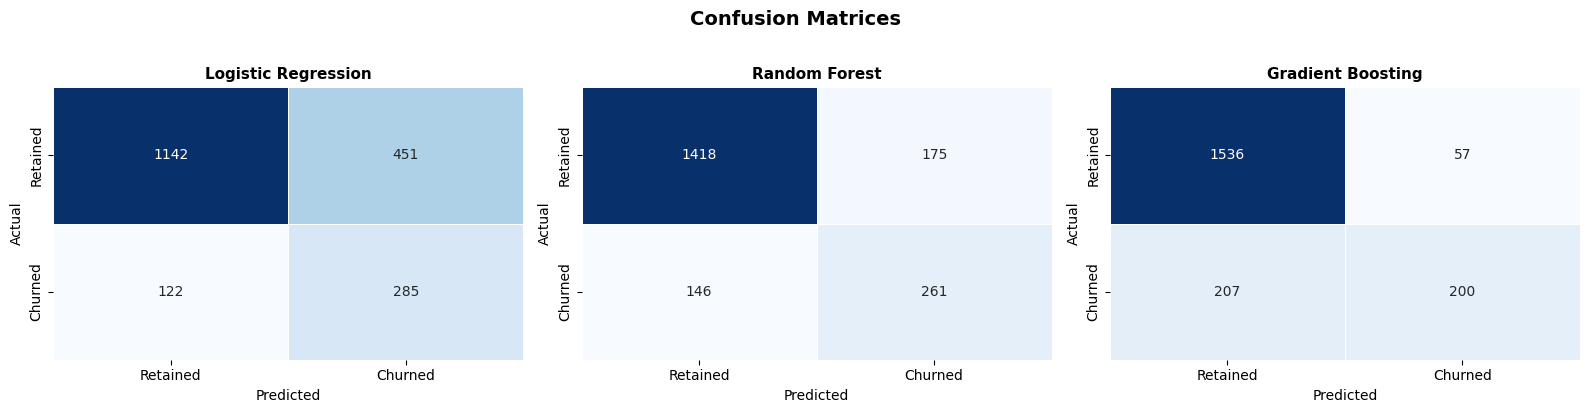

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

model_names = list(results.keys())
preds       = [lr_pred, rf_pred, gb_pred]

for ax, name, pred in zip(axes, model_names, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

 ROC Curves

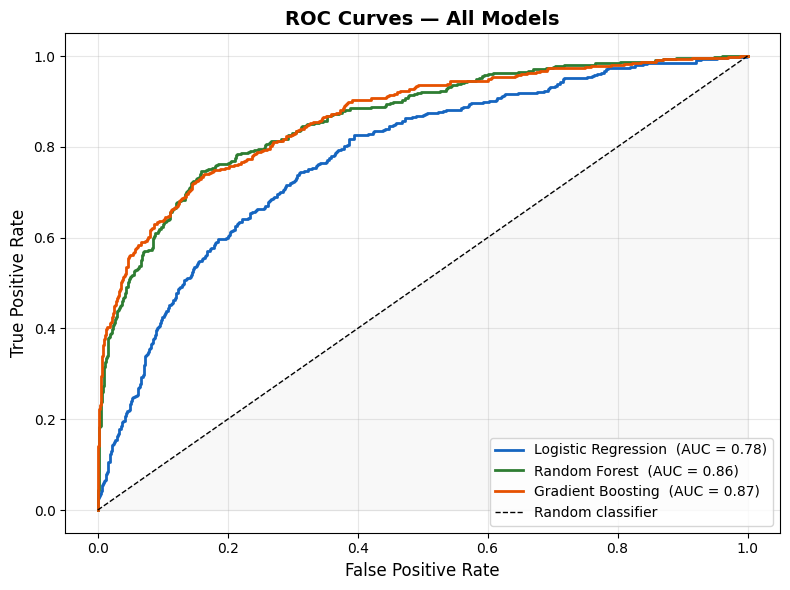

In [18]:
plt.figure(figsize=(8, 6))

colors = ['#1565C0', '#2E7D32', '#E65100']
probs  = [lr_prob, rf_prob, gb_prob]

for name, prob, color in zip(model_names, probs, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.2f})',
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

 Feature Importance (Random Forest)

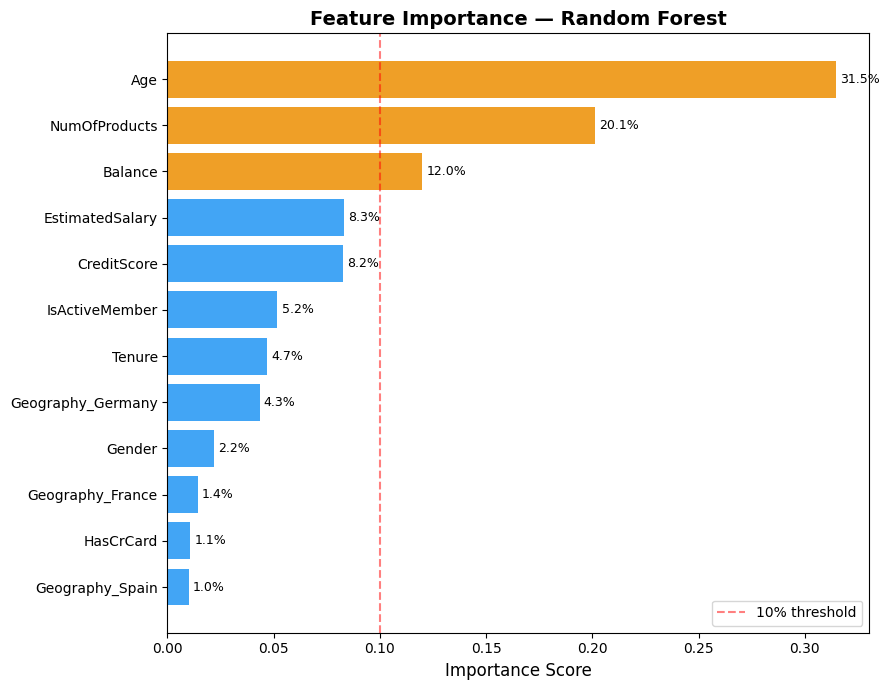


Top 5 most important features:
  Age                    31.46%
  NumOfProducts          20.13%
  Balance                12.00%
  EstimatedSalary        8.29%
  CreditScore            8.25%


In [19]:
feature_names = X.columns.tolist()
importances   = rf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))
colors_bar = ['#EF9F27' if v > 0.1 else '#42A5F5' for v in fi_df['Importance']]
bars = plt.barh(fi_df['Feature'], fi_df['Importance'],
                color=colors_bar, edgecolor='none')

for bar, val in zip(bars, fi_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='10% threshold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
top5 = fi_df.sort_values('Importance', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['Feature']:<22} {row['Importance']*100:.2f}%")






Cross-Validation (Random Forest)

In [20]:
# ──  ───────────────────────────────
print("Running 5-fold cross-validation on Random Forest...\n")

cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=10,
                           random_state=42, class_weight='balanced', n_jobs=-1),
    X, y, cv=5, scoring='roc_auc'
)

print("CV AUC scores per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score*100:.2f}%")

print(f"\nMean AUC : {cv_scores.mean()*100:.2f}%")
print(f"Std  AUC : {cv_scores.std()*100:.2f}%")

Running 5-fold cross-validation on Random Forest...

CV AUC scores per fold:
  Fold 1: 85.69%
  Fold 2: 86.57%
  Fold 3: 85.90%
  Fold 4: 86.11%
  Fold 5: 85.48%

Mean AUC : 85.95%
Std  AUC : 0.38%


Business Insights Summary

In [23]:


print("=" * 55)
print("  CUSTOMER CHURN PREDICTION — FINDINGS SUMMARY")
print("=" * 55)

print("\n📌 TOP FEATURES DRIVING CHURN (Random Forest):")
print("   1. Age             → 31.5%  (biggest driver by far)")
print("   2. NumOfProducts   → 20.1%  (2nd most important)")
print("   3. Balance         → 12.0%  (above 10% threshold)")
print("   4. EstimatedSalary →  8.3%")
print("   5. CreditScore     →  8.2%")
print("   6. IsActiveMember  →  5.2%")
print("   7. Tenure          →  4.7%")
print("   8. Geography_Germany→ 4.3%")

print("\n📌 WHAT THIS MEANS FOR THE BANK:")
print("   • Age is the #1 risk factor — older customers")
print("     are far more likely to leave the bank")
print("   • Customers with 3 or 4 products churn more")
print("     despite seeming deeply engaged")
print("   • High balance customers are also at risk —")
print("     they likely have better options elsewhere")
print("   • Inactive members churn silently — bank must")
print("     re-engage them before it is too late")
print("   • Germany branch needs special attention —")
print("     higher churn rate than France and Spain")

print("\n📌 MODEL COMPARISON RESULTS:")
print("   Logistic Regression → AUC 77.71% | Recall 70%")
print("   Random Forest       → AUC 86.16% | Recall 64%")
print("   Gradient Boosting   → AUC 86.54% | Recall 49%")

print("\n📌 BEST MODEL = RANDOM FOREST ✅")
print("   • Gradient Boosting looks best on accuracy")
print("     but misses 51% of real churners — too risky")
print("   • Random Forest gives the best BALANCE between")
print("     catching churners (64%) and precision (60%)")
print("   • AUC of 86.16% means strong ranking ability")

print("\n📌 BANK ACTION PLAN:")
print("   → Send retention offers to customers aged 50+")
print("   → Call inactive members before they close account")
print("   → Investigate why Germany has higher churn")
print("   → Review product bundles — 3-4 products = red flag")
print("   → Monitor high balance customers closely")

print("\n" + "=" * 55)
print("  PROJECT COMPLETE ✅")
print("=" * 55)

  CUSTOMER CHURN PREDICTION — FINDINGS SUMMARY

📌 TOP FEATURES DRIVING CHURN (Random Forest):
   1. Age             → 31.5%  (biggest driver by far)
   2. NumOfProducts   → 20.1%  (2nd most important)
   3. Balance         → 12.0%  (above 10% threshold)
   4. EstimatedSalary →  8.3%
   5. CreditScore     →  8.2%
   6. IsActiveMember  →  5.2%
   7. Tenure          →  4.7%
   8. Geography_Germany→ 4.3%

📌 WHAT THIS MEANS FOR THE BANK:
   • Age is the #1 risk factor — older customers
     are far more likely to leave the bank
   • Customers with 3 or 4 products churn more
     despite seeming deeply engaged
   • High balance customers are also at risk —
     they likely have better options elsewhere
   • Inactive members churn silently — bank must
     re-engage them before it is too late
   • Germany branch needs special attention —
     higher churn rate than France and Spain

📌 MODEL COMPARISON RESULTS:
   Logistic Regression → AUC 77.71% | Recall 70%
   Random Forest       → AUC 86.16